### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mlxtend.frequent_patterns as fp
%matplotlib inline

from IPython.display import display
from datetime import date

### Load Train Dataset

In [2]:
df_train = pd.read_csv("train.csv")
display(df_train)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5,1
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3,0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3,1
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0,0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0,0
439136,439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0,0
439137,439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0,0
439138,439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1,0


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [4]:
df_train.dtypes

id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change             int64
PitNextLap                  int64
dtype: object

In [5]:
df_train.shape

(439140, 16)

In [6]:
df_train.size

7026240

In [7]:
df_train.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

In [8]:
df_train.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [9]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [10]:
df_train.describe(include=['object'])

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


In [11]:
duplicates = df_train.duplicated().sum()
print(duplicates)

0


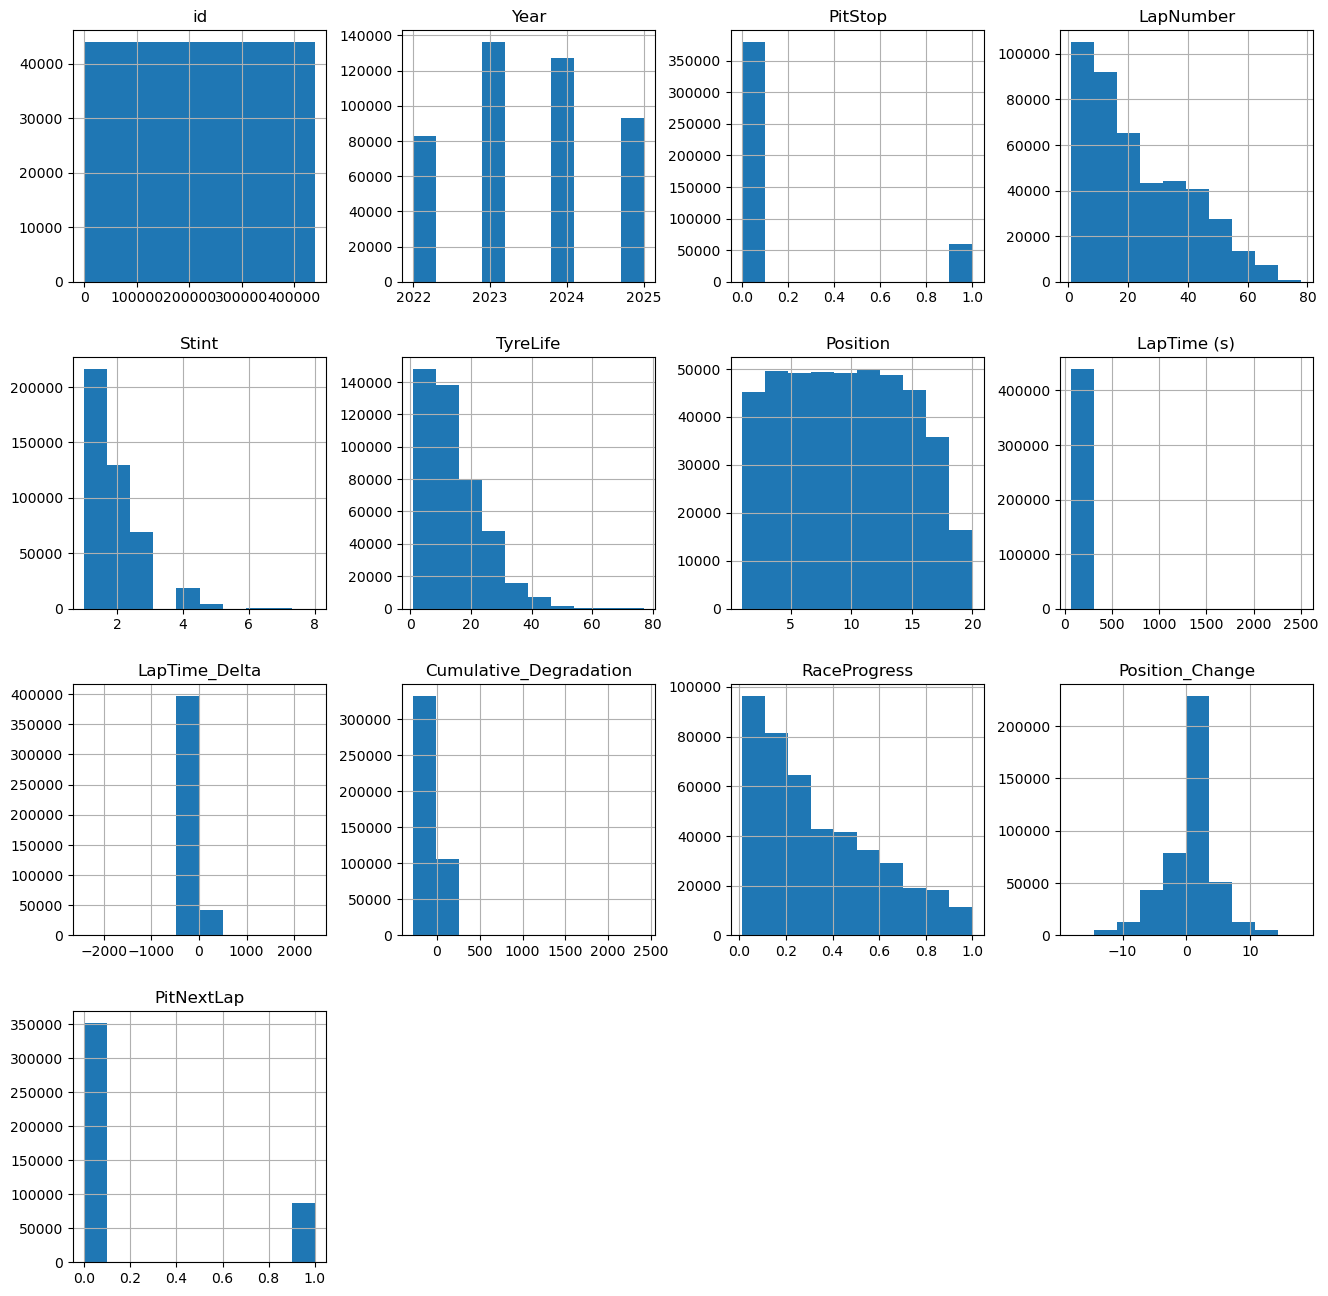

In [53]:
df_train.hist(figsize = (16,16));

In [12]:
df_train['Driver'].unique()

array(['D109', 'D086', 'ZON', 'SPE', 'D019', 'D012', 'D104', 'D082',
       'BEL', 'YAM', 'MAS', 'D010', 'D063', 'D196', 'D132', 'D047', 'PRO',
       'D066', 'DRA', 'PEA', 'HAD', 'HUL', 'COU', 'D036', 'D205', 'BER',
       'VIL', 'GUT', 'TUR', 'D089', 'D055', 'D189', 'D071', 'DAM', 'D144',
       'D384', 'D263', 'D117', 'D120', 'D054', 'D184', 'D214', 'IDE',
       'D216', 'D101', 'D160', 'WIL', 'CAR', 'D251', 'D106', 'D083',
       'WAR', 'D065', 'MIN', 'D293', 'BIA', 'D125', 'D073', 'ALE', 'D007',
       'D009', 'D202', 'NOR', 'FRE', 'D057', 'D177', 'D049', 'ALG', 'SUT',
       'D312', 'D159', 'D219', 'ROS', 'D166', 'D218', 'D045', 'D197',
       'GIO', 'DIR', 'D138', 'WEB', 'D070', 'D097', 'LEC', 'D050', 'D369',
       'HYD', 'D355', 'D032', 'D292', 'BEA', 'D001', 'D232', 'D211',
       'DIN', 'D157', 'NAK', 'TAY', 'STR', 'D325', 'D028', 'RIC', 'ZHO',
       'GAS', 'D041', 'D014', 'D283', 'WUR', 'D061', 'D281', 'D046',
       'TSU', 'D170', 'D122', 'D210', 'D191', 'D074', 'SHA', 'D

In [13]:
df_train['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET'], dtype=object)

In [14]:
df_train['Race'].unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix'], dtype=object)

In [15]:
df_train['Year'].unique()

array([2022, 2025, 2023, 2024])

In [16]:
df_train['PitStop'].unique()

array([0, 1])

In [17]:
df_train['Stint'].unique()

array([2, 3, 1, 4, 5, 6, 8, 7])

In [18]:
df_train['TyreLife'].unique()

array([39. ,  7. , 22. ,  2. ,  6. , 26. , 16. ,  9. ,  4. , 10. , 12. ,
        1. ,  5. , 18. ,  8. , 17. , 19. , 14. , 15. , 27. , 13. , 24. ,
       37. , 21. , 32. , 20. , 23. , 11. , 25. , 29. , 38. ,  3. , 45. ,
       30. , 34. , 40. , 28. , 36. , 31. , 49. , 41. , 35. , 44. , 33. ,
       50. , 42. , 46. , 67. , 61. , 63. , 47. , 52. , 48. , 43. , 56. ,
       55. , 53. , 51. , 66. , 54. , 60. , 73. , 70. , 72. , 58. , 74. ,
       68. , 64. , 62. , 65. , 59. , 69. , 57. , 71. , 75. , 76. , 77. ,
       60.5])

In [19]:
df_train['Position'].unique()

array([ 8,  4, 13,  7,  2,  5, 11,  1, 12, 10, 18, 15,  3, 20,  6, 17,  9,
       14, 16, 19])

In [20]:
df_train['PitNextLap'].unique()

array([1, 0])

## Exploratory Data Analysis

### Driver Distribution

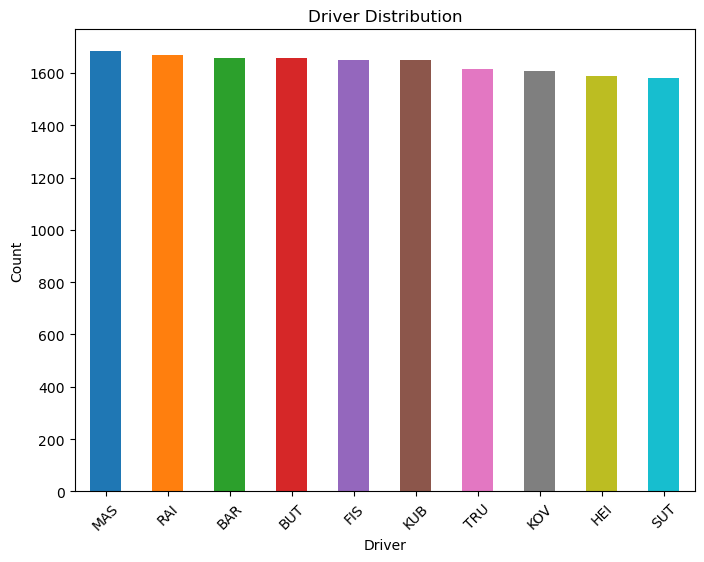

In [21]:
plt.figure(figsize=(8, 6))
df_train['Driver'].value_counts().head(10).plot(
    kind='bar', 
    color=plt.cm.tab10.colors
)

plt.title('Driver Distribution')
plt.xlabel('Driver')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Pit Stop Percentage

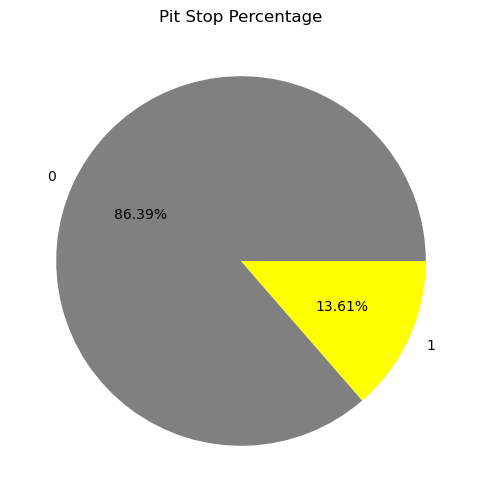

In [22]:
plt.figure(figsize=(8, 6))
df_train['PitStop'].value_counts().plot(
    kind='pie', 
    colors=['gray', 'yellow'], 
    autopct='%1.2f%%'
)

plt.title('Pit Stop Percentage')
plt.ylabel('')
plt.show()

### Pit Stop Distribution

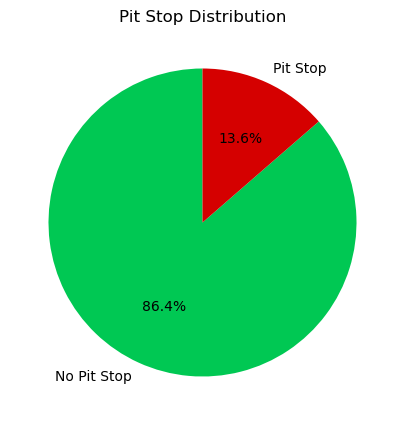

In [23]:
plt.figure(figsize=(7,5))

pit_counts = df_train['PitStop'].value_counts()

plt.pie(
    pit_counts,
    labels=['No Pit Stop', 'Pit Stop'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#00C853', '#D50000']
)

plt.title('Pit Stop Distribution')
plt.show()

### Top Drivers By Pit Stop Frequency

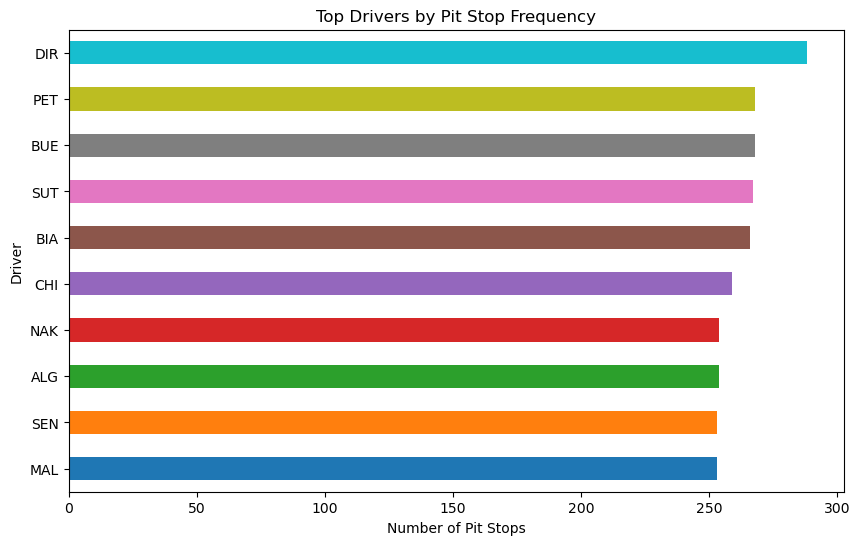

In [24]:
plt.figure(figsize=(10,6))

driver_pits = (
    df_train[df_train['PitStop'] == 1]['Driver']
    .value_counts()
    .head(10)
    .sort_values()
)

driver_pits.plot(
    kind='barh',
    color=plt.cm.tab10.colors
)

plt.title('Top Drivers by Pit Stop Frequency')
plt.xlabel('Number of Pit Stops')
plt.ylabel('Driver')
plt.show()

### Tyre Compound Distribution

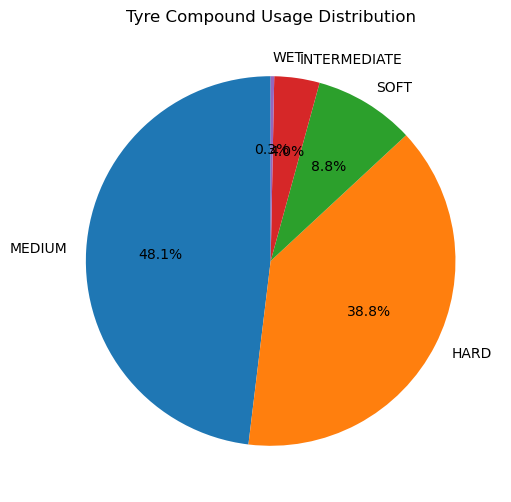

In [25]:
plt.figure(figsize=(8,6))

compound_counts = df_train['Compound'].value_counts()

plt.pie(
    compound_counts,
    labels=compound_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Tyre Compound Usage Distribution')
plt.show()

### Tyre Life Distribution

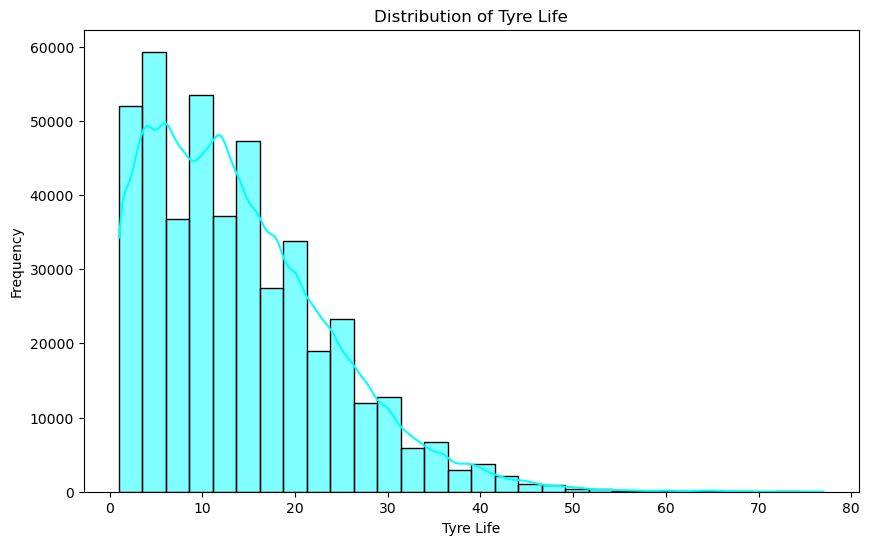

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_train,
    x='TyreLife',
    bins=30,
    kde=True,
    color='cyan'
)

plt.title('Distribution of Tyre Life')
plt.xlabel('Tyre Life')
plt.ylabel('Frequency')
plt.show()

### Tyre Life vs Pit Stop

C:\Users\enoch\AppData\Local\Temp\ipykernel_30400\1841256031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


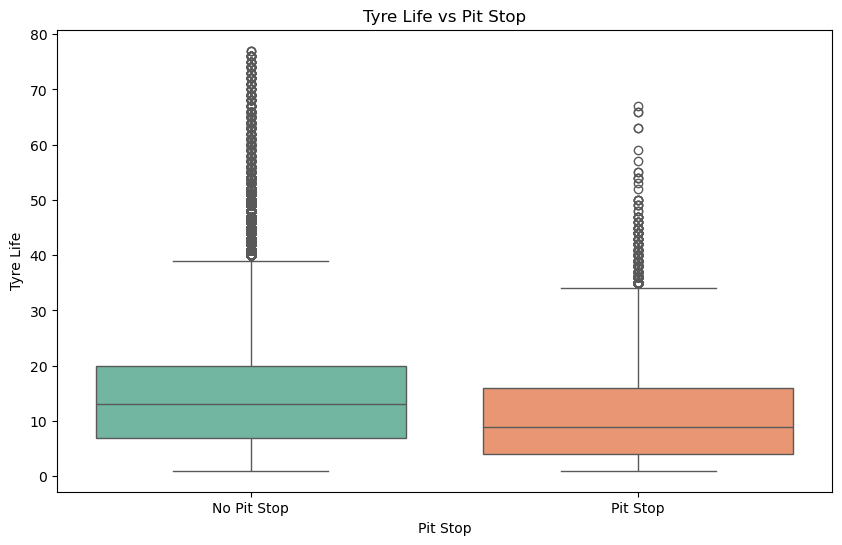

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_train,
    x='PitStop',
    y='TyreLife',
    palette='Set2'
)

plt.title('Tyre Life vs Pit Stop')
plt.xlabel('Pit Stop')
plt.ylabel('Tyre Life')
plt.xticks([0,1], ['No Pit Stop', 'Pit Stop'])
plt.show()

### Race Position vs Pit Stop

C:\Users\enoch\AppData\Local\Temp\ipykernel_30400\43094176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


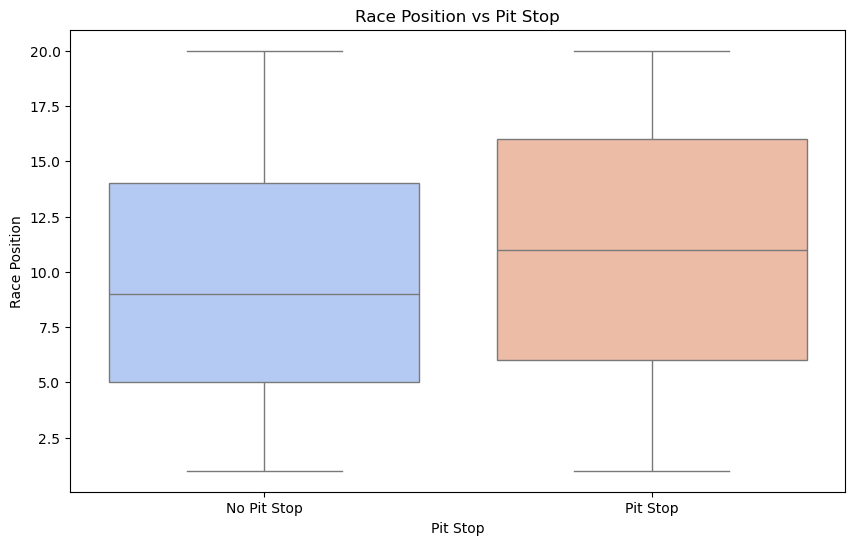

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_train,
    x='PitStop',
    y='Position',
    palette='coolwarm'
)

plt.title('Race Position vs Pit Stop')
plt.xlabel('Pit Stop')
plt.ylabel('Race Position')
plt.xticks([0,1], ['No Pit Stop', 'Pit Stop'])
plt.show()

### Stint Distribution

C:\Users\enoch\AppData\Local\Temp\ipykernel_30400\2974569582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


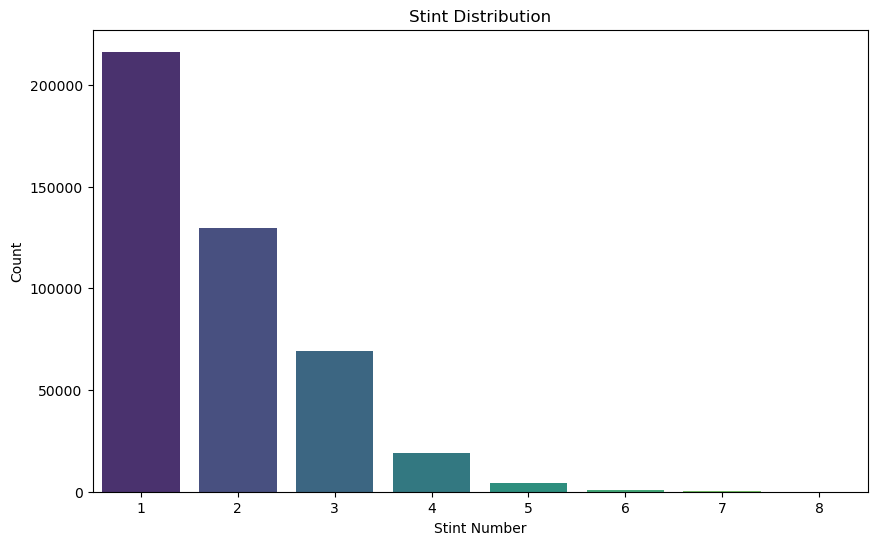

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_train,
    x='Stint',
    palette='viridis'
)

plt.title('Stint Distribution')
plt.xlabel('Stint Number')
plt.ylabel('Count')
plt.show()

### Pit Stops by Year

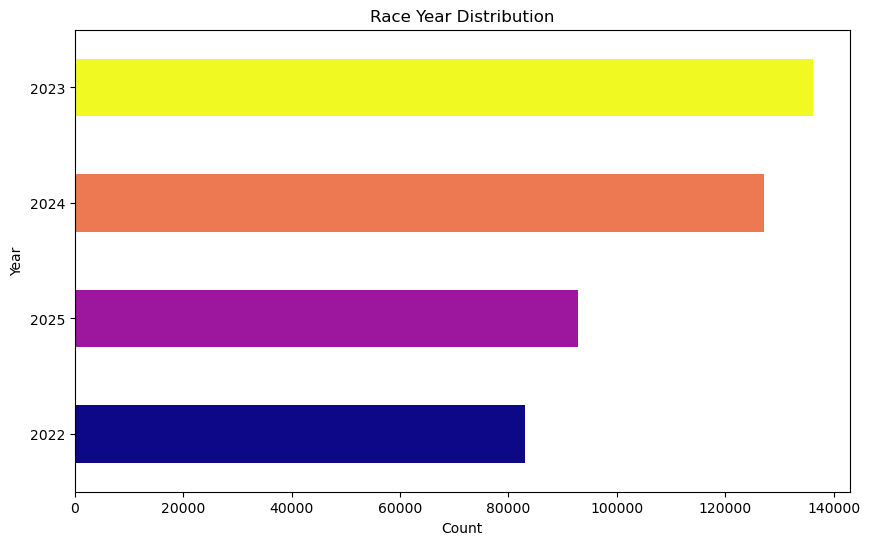

In [30]:
plt.figure(figsize=(10,6))

year_counts = (
    df_train['Year']
    .value_counts()
    .head(10)
    .sort_values()
)

year_counts.plot(
    kind='barh',
    color=plt.cm.plasma(np.linspace(0,1,len(year_counts)))
)

plt.title('Race Year Distribution')
plt.xlabel('Count')
plt.ylabel('Year')
plt.show()

### Tyre Compound vs Tyre Life

C:\Users\enoch\AppData\Local\Temp\ipykernel_30400\3297371960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


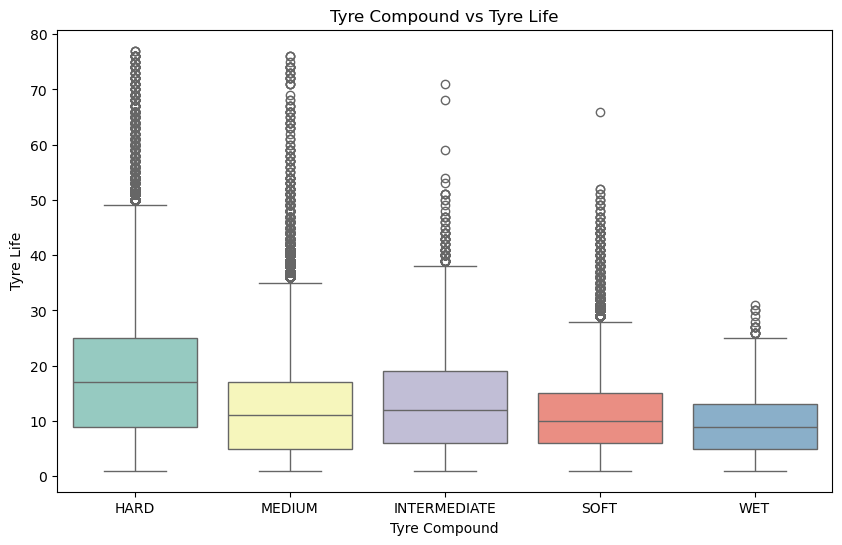

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_train,
    x='Compound',
    y='TyreLife',
    palette='Set3'
)

plt.title('Tyre Compound vs Tyre Life')
plt.xlabel('Tyre Compound')
plt.ylabel('Tyre Life')
plt.show()

### Driver Strategy Analysis

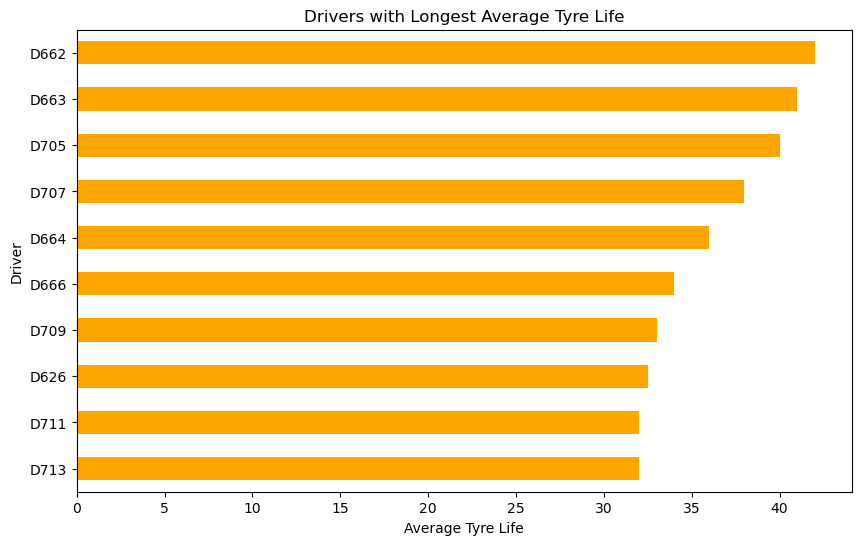

In [32]:
driver_avg_tyre = (
    df_train.groupby('Driver')['TyreLife']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

driver_avg_tyre.sort_values().plot(
    kind='barh',
    color='orange'
)

plt.title('Drivers with Longest Average Tyre Life')
plt.xlabel('Average Tyre Life')
plt.ylabel('Driver')
plt.show()

### Correlation Heatmap

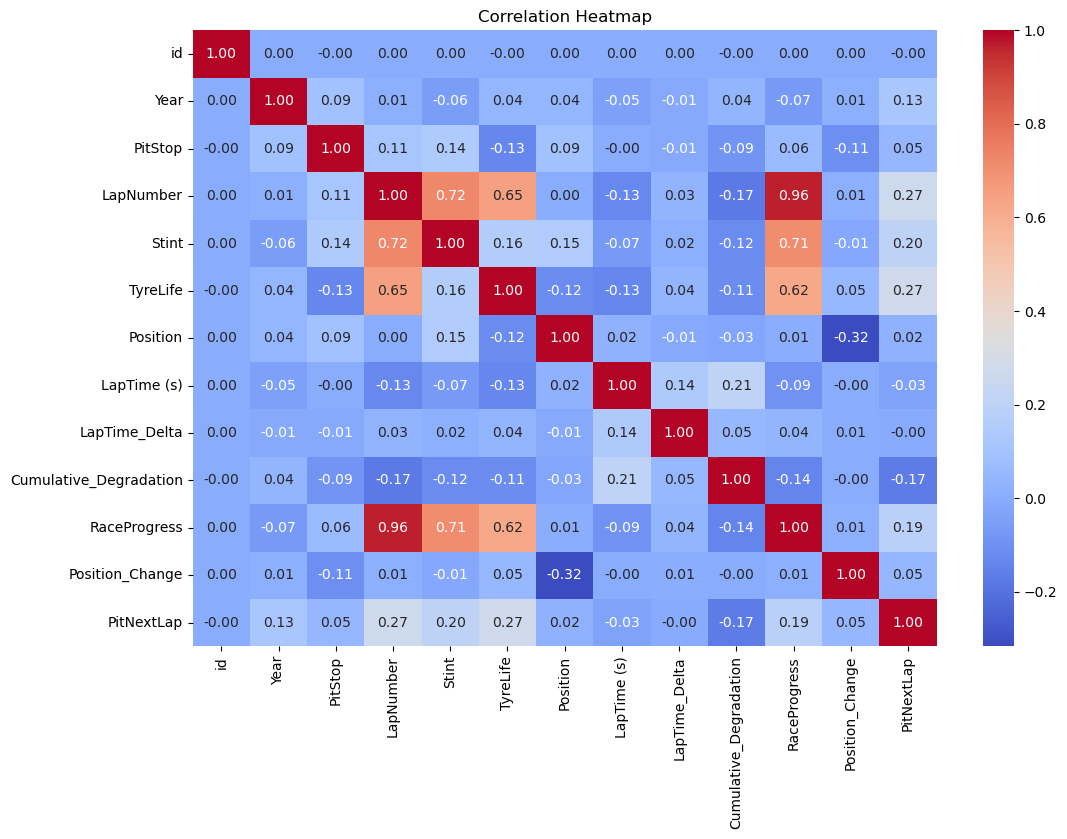

In [33]:
numeric_df = df_train.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

### Pit Stop Probability Based on Tyre Life

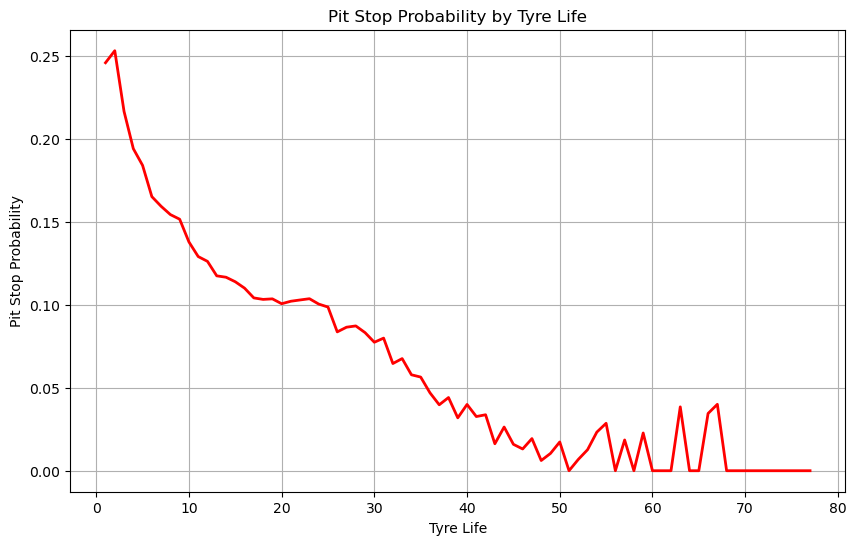

In [34]:
pit_probability = (
    df_train.groupby('TyreLife')['PitStop']
    .mean()
)

plt.figure(figsize=(10,6))

pit_probability.plot(
    color='red',
    linewidth=2
)

plt.title('Pit Stop Probability by Tyre Life')
plt.xlabel('Tyre Life')
plt.ylabel('Pit Stop Probability')
plt.grid(True)
plt.show()

### Driver vs Compound Heatmap

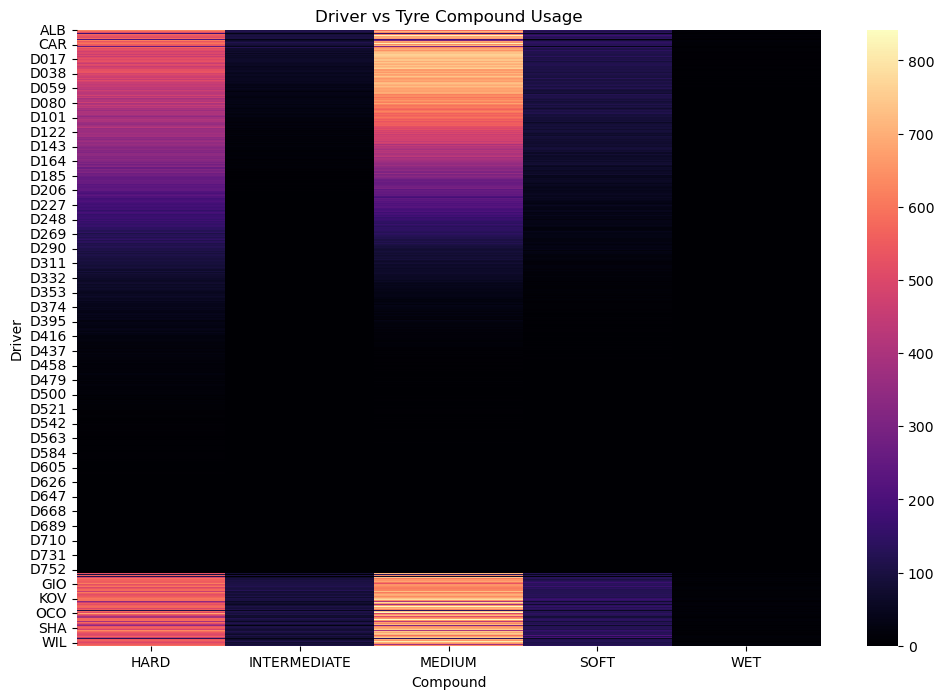

In [35]:
driver_compound = pd.crosstab(
    df_train['Driver'],
    df_train['Compound']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    driver_compound,
    cmap='magma'
)

plt.title('Driver vs Tyre Compound Usage')
plt.xlabel('Compound')
plt.ylabel('Driver')
plt.show()

### Tyre Life vs Position Scatter Plot

C:\Users\enoch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


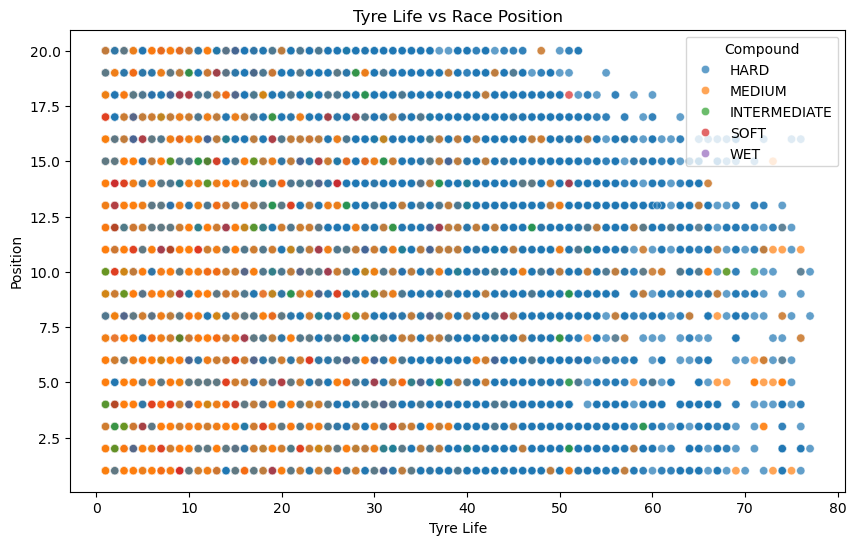

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_train,
    x='TyreLife',
    y='Position',
    hue='Compound',
    alpha=0.7
)

plt.title('Tyre Life vs Race Position')
plt.xlabel('Tyre Life')
plt.ylabel('Position')
plt.show()

### Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [63]:
le = LabelEncoder() 
# Encode categorical columns 
categorical_cols = ['Driver', 'Compound', 'Race'] 
for col in categorical_cols: 
    df_train[col] = le.fit_transform(df_train[col])

NameError: name 'LabelEncoder' is not defined

In [56]:
#split dataset in features and target variable
feature_cols = ['TyreLife', 'Compound', 'Stint', 'Position', 'LapNumber', 'Driver', 'Race', 'Year']
X = df_train[feature_cols] # Features
y = df_train.PitStop # Target variable

##### Train and Test Split

In [57]:
# split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [58]:
# create the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

# make prediction
y_pred = logreg.predict(X_test)

ValueError: could not convert string to float: 'MEDIUM'

In [ ]:
# evaluate the model
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

In [ ]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

In [ ]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

### Load Test Dataset

In [37]:
df_test = pd.read_csv("test.csv")
display(df_test)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,D171,MEDIUM,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0
188161,627301,RUS,SOFT,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0
188162,627302,D112,MEDIUM,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0
188163,627303,D349,MEDIUM,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0


In [38]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      188165 non-null  int64  
 1   Driver                  188165 non-null  object 
 2   Compound                188165 non-null  object 
 3   Race                    188165 non-null  object 
 4   Year                    188165 non-null  int64  
 5   PitStop                 188165 non-null  int64  
 6   LapNumber               188165 non-null  int64  
 7   Stint                   188165 non-null  int64  
 8   TyreLife                188165 non-null  float64
 9   Position                188165 non-null  int64  
 10  LapTime (s)             188165 non-null  float64
 11  LapTime_Delta           188165 non-null  float64
 12  Cumulative_Degradation  188165 non-null  float64
 13  RaceProgress            188165 non-null  float64
 14  Position_Change     

In [39]:
df_test.dtypes

id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
dtype: object

Test Dataset datatype comparison: 
- Position_Change is int64
- No PitNextLap column

In [40]:
df_test.shape

(188165, 15)

In [41]:
df_test.size

2822475

In [42]:
df_test.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change'],
      dtype='object')

In [43]:
df_test.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

In [44]:
df_test.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,533222.000000,2023.528440,0.136263,23.050185,1.784237,14.160625,9.604539,90.986869,-3.577802,-25.849491,0.336695,0.106800
std,54318.701038,1.025376,0.343069,17.002292,0.948800,9.852778,5.273444,20.855248,40.348466,54.920269,0.253396,4.020592
min,439140.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.216000,-274.564000,0.012821,-18.000000
25%,486181.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.634000,-8.874000,-46.814000,0.128205,-1.000000
50%,533222.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.485000,-0.285000,-21.027000,0.269231,0.000000
75%,580263.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.485000,0.122000,-6.188000,0.512821,2.000000
max,627304.000000,2025.000000,1.000000,77.000000,8.000000,77.000000,20.000000,2497.905000,2433.472000,2406.800000,1.000000,18.000000


In [45]:
df_test.describe(include=['object'])

,Driver,Compound,Race
count,188165,188165,188165
unique,801,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,743,90897,10340


In [46]:
duplicates = df_test.duplicated().sum()
print(duplicates)

0
